In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
DATA_DIR  = Path('../data/processed')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

COPD_RED  = '#D62728'
SAFE_BLUE = '#1F77B4'

print('Setup good')

Setup good


In [17]:
df22 = pd.read_csv(DATA_DIR / 'brfss_2022_clean.csv')
df23 = pd.read_csv(DATA_DIR / 'brfss_2023_clean.csv')
df_all = pd.concat([df22, df23], ignore_index=True)

print(f'2022 : {len(df22):,} rows × {df22.shape[1]} cols')
print(f'2023 : {len(df23):,} rows × {df23.shape[1]} cols')
print(f'Pool : {len(df_all):,} rows')
print()
print('Columns:', df22.columns.tolist())

2022 : 442,913 rows × 30 cols
2023 : 431,257 rows × 30 cols
Pool : 874,170 rows

Columns: ['CHCCOPD3', 'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE', 'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', 'EXERANY2', 'DRNKANY6', '_BMI5CAT', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', '_LLCPWT', '_STSTR', '_PSU', 'YEAR', 'COPD', 'DIABETES', 'PREDIABETES']


In [18]:
OUTCOME = 'COPD'
WEIGHT  = '_LLCPWT'

FEATURE_COLS = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', 'EXERANY2',
    'DRNKANY6', '_BMI5CAT', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4',
    'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'PERSDOC3',
    'MEDCOST1', 'CHECKUP1', 'DIABETES', 'PREDIABETES'
]

VAR_LABELS = {
    'INCOME3'    : 'Household income (1–11)',
    'EDUCA'      : 'Education level (1–6)',
    'SEXVAR'     : 'Sex',
    '_AGEG5YR'   : 'Age group (5-yr bands)',
    '_IMPRACE'   : 'Race/ethnicity',
    'EMPLOY1'    : 'Employment status',
    'MARITAL'    : 'Marital status',
    '_URBSTAT'   : 'Urban/Rural',
    '_SMOKER3'   : 'Smoking status',
    'EXERANY2'   : 'Any exercise (past 30d)',
    'DRNKANY6'   : 'Any alcohol (past 30d)',
    '_BMI5CAT'   : 'BMI category',
    'ASTHMA3'    : 'Asthma',
    'CVDINFR4'   : 'Heart attack',
    'CVDCRHD4'   : 'Coronary heart disease',
    'CVDSTRK3'   : 'Stroke',
    'HAVARTH3'   : 'Arthritis',
    'CHCKDNY2'   : 'Kidney disease',
    'HLTHPLN2'   : 'Health insurance',
    'PERSDOC3'   : 'Has personal doctor',
    'MEDCOST1'   : 'Cost barrier to care',
    'CHECKUP1'   : 'Last routine checkup',
    'DIABETES'   : 'Diabetes',
    'PREDIABETES': 'Pre-diabetes',
}

missing_cols = [c for c in FEATURE_COLS if c not in df22.columns]
if missing_cols:
    print(f'WARNING — columns missing from df22: {missing_cols}')
else:
    print(f'All {len(FEATURE_COLS)} feature columns confirmed present.')

All 24 feature columns confirmed present.


In [19]:
# CELL 5: Investigate _AGEG5YR 17% missingness

for label, df in [('2022', df22), ('2023', df23)]:
    print(f'_AGEG5YR value counts — {label} (from cleaned CSV, NaN already applied):')
    vc = df['_AGEG5YR'].value_counts(dropna=False).sort_index()
    total = len(df)
    for val, count in vc.items():
        label_str = '← refused/DK (correctly NaN)' if pd.isna(val) else ''
        print(f'  {str(val):>6}  {count:>8,}  ({count/total*100:.1f}%)  {label_str}')
    print(f'  NaN total: {df["_AGEG5YR"].isna().sum():,} ({df["_AGEG5YR"].isna().mean()*100:.1f}%)')
    print()

print('If NaN % matches the 17% from notebook 01, the missingness is genuine')
print('refused/DK responses — no bug. Age will be kept as-is and imputed')
print('at the modelling stage alongside other high-missingness variables.')

_AGEG5YR value counts — 2022 (from cleaned CSV, NaN already applied):
     1.0    26,828  (6.1%)  
     2.0    21,888  (4.9%)  
     3.0    25,712  (5.8%)  
     4.0    28,445  (6.4%)  
     5.0    29,847  (6.7%)  
     6.0    28,442  (6.4%)  
     7.0    33,527  (7.6%)  
     8.0    36,652  (8.3%)  
     9.0    44,278  (10.0%)  
    10.0    46,907  (10.6%)  
    11.0    43,276  (9.8%)  
    12.0    32,347  (7.3%)  
    13.0    35,948  (8.1%)  
     nan     8,816  (2.0%)  ← refused/DK (correctly NaN)
  NaN total: 8,816 (2.0%)

_AGEG5YR value counts — 2023 (from cleaned CSV, NaN already applied):
     1.0    26,152  (6.1%)  
     2.0    21,182  (4.9%)  
     3.0    24,710  (5.7%)  
     4.0    27,055  (6.3%)  
     5.0    28,361  (6.6%)  
     6.0    26,987  (6.3%)  
     7.0    31,187  (7.2%)  
     8.0    34,096  (7.9%)  
     9.0    41,818  (9.7%)  
    10.0    45,904  (10.6%)  
    11.0    43,330  (10.0%)  
    12.0    34,372  (8.0%)  
    13.0    38,545  (8.9%)  
     nan     7,558

In [20]:
#Cell 6: missing data summary

DESIGN_COLS = ['_LLCPWT', '_STSTR', '_PSU', 'YEAR', 'COPD', 'CHCCOPD3']

def missing_summary(df, label):
    cols = [c for c in FEATURE_COLS if c in df.columns]
    miss = df[cols].isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f'{label}:')
    for col, pct in miss.items():
        flag = '  ⚠ HIGH' if pct > 0.10 else ''
        print(f'  {col:<16} {pct*100:5.1f}%{flag}')
    any_missing = df[cols].isna().any(axis=1).mean() * 100
    print(f'  Rows with ANY missing feature: {any_missing:.1f}%')
    print()
    return miss

miss22 = missing_summary(df22, '2022')
miss23 = missing_summary(df23, '2023')

print('Strategy for modelling notebooks:')
print('  INCOME3 / EMPLOY1 / _AGEG5YR / _BMI5CAT — high missing,')
print('  complete-case for INCOME3 interaction analysis (notebook 06).')
print('  Remaining features (<10%) — median/mode imputation in notebook 03.')

2022:
  INCOME3           21.5%  ⚠ HIGH
  _BMI5CAT          10.9%  ⚠ HIGH
  DRNKANY6          10.4%  ⚠ HIGH
  _SMOKER3           7.9%
  HLTHPLN2           4.0%
  EMPLOY1            2.5%
  _URBSTAT           2.1%
  _AGEG5YR           2.0%
  CHECKUP1           1.3%
  MARITAL            1.0%
  PERSDOC3           1.0%
  CVDCRHD4           0.9%
  CVDINFR4           0.6%
  HAVARTH3           0.5%
  EDUCA              0.5%
  CHCKDNY2           0.4%
  MEDCOST1           0.3%
  ASTHMA3            0.3%
  CVDSTRK3           0.3%
  EXERANY2           0.2%
  DIABETES           0.2%
  PREDIABETES        0.2%
  Rows with ANY missing feature: 36.7%

2023:
  INCOME3           19.9%  ⚠ HIGH
  _BMI5CAT           9.3%
  DRNKANY6           6.9%
  _SMOKER3           5.3%
  HLTHPLN2           4.3%
  _URBSTAT           1.9%
  _AGEG5YR           1.8%
  EMPLOY1            1.7%
  CHECKUP1           1.3%
  MARITAL            1.0%
  PERSDOC3           1.0%
  CVDCRHD4           0.9%
  CVDINFR4           0.5%
  HAVA

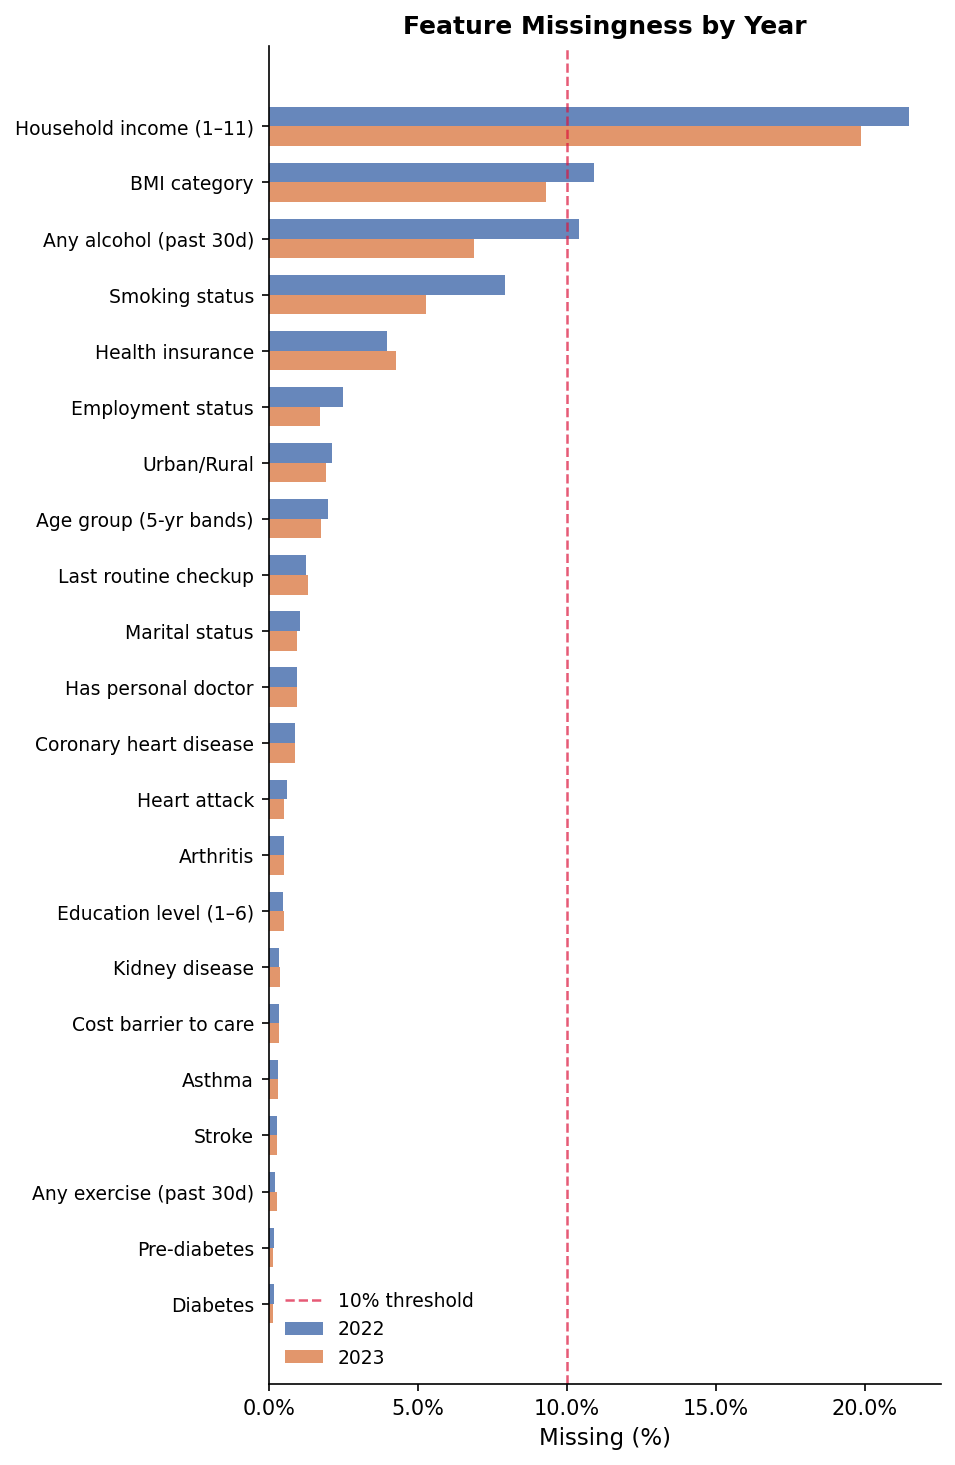

Saved fig01_missingness.png


In [21]:
#CELL 7: Missing data figure 

miss_df = pd.DataFrame({'2022': miss22 * 100, '2023': miss23 * 100}).fillna(0)
miss_df = miss_df[miss_df.max(axis=1) > 0].sort_values('2022', ascending=False)
pretty_idx = [VAR_LABELS.get(v, v) for v in miss_df.index]

fig, ax = plt.subplots(figsize=(6.5, max(3, len(miss_df) * 0.45)))
x = np.arange(len(miss_df))
w = 0.35

ax.barh(x - w/2, miss_df['2022'], w, label='2022', color='#4C72B0', alpha=0.85)
ax.barh(x + w/2, miss_df['2023'], w, label='2023', color='#DD8452', alpha=0.85)
ax.axvline(10, color='crimson', lw=1.2, ls='--', alpha=0.7, label='10% threshold')

ax.set_yticks(x)
ax.set_yticklabels(pretty_idx, fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Feature Missingness by Year')
ax.legend(frameon=False, fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_missingness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig01_missingness.png')

In [22]:
# Cell 8: Weighted prevalence estimates

def weighted_prev(df):
    w    = df[WEIGHT].fillna(0)
    y    = df[OUTCOME].astype(float)
    p    = np.average(y, weights=w)
    neff = (w.sum() ** 2) / (w ** 2).sum()
    se   = np.sqrt(p * (1 - p) / neff)
    return p * 100, (p - 1.96 * se) * 100, (p + 1.96 * se) * 100

p22,  lo22,  hi22  = weighted_prev(df22)
p23,  lo23,  hi23  = weighted_prev(df23)
pall, loall, hiall = weighted_prev(df_all)

print('=== Survey-weighted COPD prevalence ===\n')
print(f'  2022  : {p22:.2f}%  (95% CI {lo22:.2f}–{hi22:.2f}%)')
print(f'  2023  : {p23:.2f}%  (95% CI {lo23:.2f}–{hi23:.2f}%)')
print(f'  Pooled: {pall:.2f}%  (95% CI {loall:.2f}–{hiall:.2f}%)')
print()
print(f'  Unweighted 2022 : {df22[OUTCOME].mean()*100:.2f}%')
print(f'  Unweighted 2023 : {df23[OUTCOME].mean()*100:.2f}%')
print()
print(f'  COPD cases — 2022: {df22[OUTCOME].sum():,}  |  2023: {df23[OUTCOME].sum():,}')
print(f'  Class ratio 2022 : 1 : {(df22[OUTCOME]==0).sum() / df22[OUTCOME].sum():.1f}')
print(f'  Class ratio 2023 : 1 : {(df23[OUTCOME]==0).sum() / df23[OUTCOME].sum():.1f}')
print()
print('Class imbalance ~1:11–12 — use class_weight="balanced" in all sklearn')
print('models. Confirm with SMOTE sensitivity check in notebook 03.')

=== Survey-weighted COPD prevalence ===

  2022  : 6.76%  (95% CI 6.60–6.92%)
  2023  : 6.19%  (95% CI 6.02–6.35%)
  Pooled: 6.48%  (95% CI 6.37–6.60%)

  Unweighted 2022 : 8.05%
  Unweighted 2023 : 7.67%

  COPD cases — 2022: 35,656  |  2023: 33,097
  Class ratio 2022 : 1 : 11.4
  Class ratio 2023 : 1 : 12.0

Class imbalance ~1:11–12 — use class_weight="balanced" in all sklearn
models. Confirm with SMOTE sensitivity check in notebook 03.


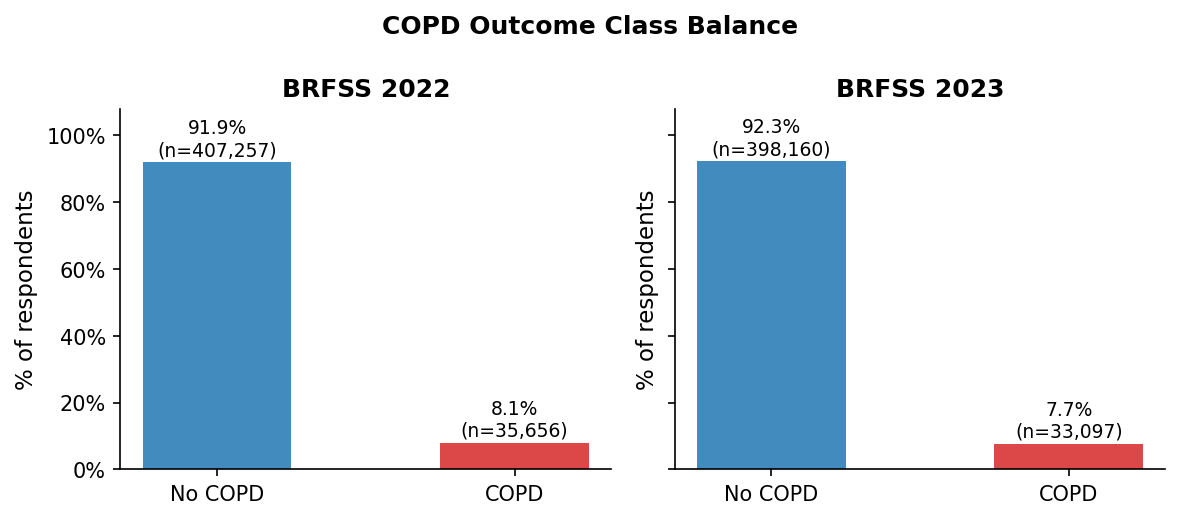

Saved fig02_class_balance.png


In [23]:
# Cell 9: Class balance figure

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)

for ax, (df, yr) in zip(axes, [(df22, 2022), (df23, 2023)]):
    counts = df[OUTCOME].value_counts().sort_index()
    pcts   = counts / counts.sum() * 100
    bars   = ax.bar(['No COPD', 'COPD'], pcts.values,
                    color=[SAFE_BLUE, COPD_RED], alpha=0.85, width=0.5)
    for bar, pct, n in zip(bars, pcts.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{pct:.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'BRFSS {yr}')
    ax.set_ylabel('% of respondents')
    ax.set_ylim(0, 108)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('COPD Outcome Class Balance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig02_class_balance.png')

In [24]:
# Cell 10: Income gradient analysis

INCOME_LABELS = {
    1: '<$10k',    2: '$10–15k',  3: '$15–20k',  4: '$20–25k',
    5: '$25–35k',  6: '$35–50k',  7: '$50–75k',  8: '$75–100k',
    9: '$100–150k',10: '$150–200k',11: '>$200k'
}

def income_gradient(df):
    rows = []
    for val in sorted(df['INCOME3'].dropna().unique()):
        sub = df[df['INCOME3'] == val]
        if len(sub) < 50:
            continue
        w    = sub[WEIGHT].fillna(0)
        y    = sub[OUTCOME].astype(float)
        p    = np.average(y, weights=w)
        neff = (w.sum() ** 2) / (w ** 2).sum()
        se   = np.sqrt(p * (1 - p) / neff)
        rows.append({
            'income_val'  : int(val),
            'income_label': INCOME_LABELS.get(int(val), str(int(val))),
            'prevalence'  : p * 100,
            'ci_lo'       : (p - 1.96 * se) * 100,
            'ci_hi'       : (p + 1.96 * se) * 100,
            'n'           : len(sub),
        })
    return pd.DataFrame(rows)

grad22 = income_gradient(df22)
grad23 = income_gradient(df23)

for label, g in [('2022', grad22), ('2023', grad23)]:
    rho, pval = spearmanr(g['income_val'], g['prevalence'])
    hi  = g.loc[g['income_val'].idxmin(), 'prevalence']
    lo  = g.loc[g['income_val'].idxmax(), 'prevalence']
    print(f'{label}:  Spearman ρ = {rho:.3f}  (p = {pval:.2e})'
          f'   |   fold-gradient = {hi/lo:.1f}×'
          f'   ({hi:.1f}% lowest vs {lo:.1f}% highest income)')

print()
print(grad22[['income_label','prevalence','ci_lo','ci_hi','n']].to_string(index=False))

2022:  Spearman ρ = -0.973  (p = 5.14e-07)   |   fold-gradient = 7.7×   (14.0% lowest vs 1.8% highest income)
2023:  Spearman ρ = -0.945  (p = 1.12e-05)   |   fold-gradient = 6.7×   (10.6% lowest vs 1.6% highest income)

income_label  prevalence     ci_lo     ci_hi     n
       <$10k   14.022381 12.650891 15.393871 10251
     $10–15k   17.384689 15.826694 18.942684 10940
     $15–20k   14.853283 13.560384 16.146182 14207
     $20–25k   11.402086 10.436066 12.368106 20226
     $25–35k    9.532188  8.928480 10.135896 42093
     $35–50k    7.511886  6.995220  8.028553 46641
     $50–75k    5.763345  5.357633  6.169057 58971
    $75–100k    4.494459  4.106721  4.882198 48319
   $100–150k    3.392934  3.062504  3.723365 50241
   $150–200k    2.722184  2.269595  3.174772 22517
      >$200k    1.815915  1.468117  2.163713 23447


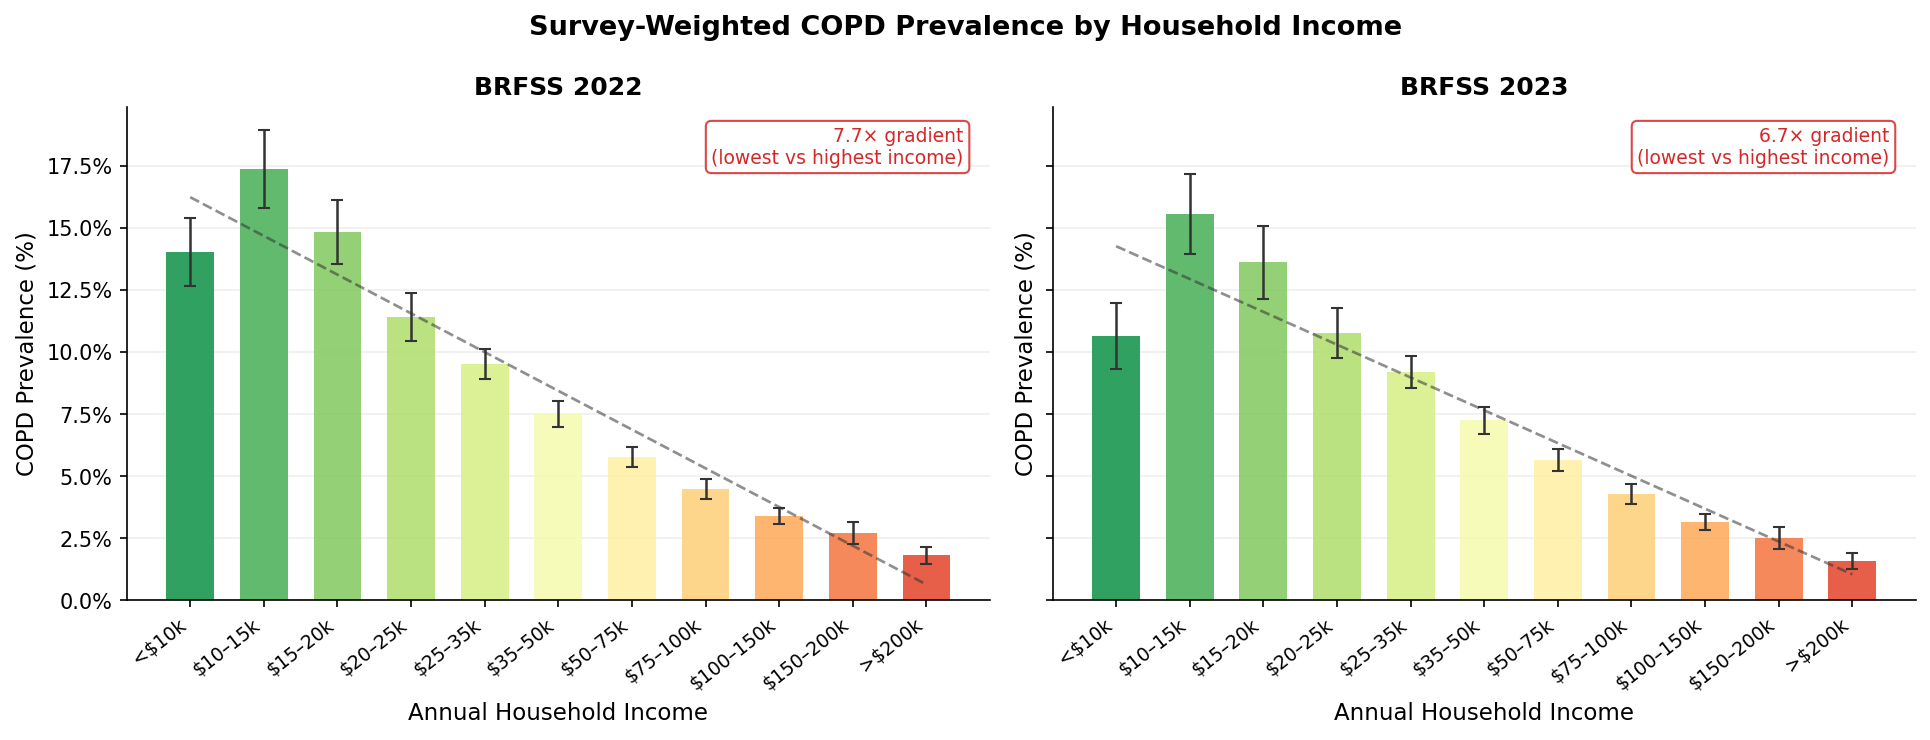

Saved fig03_income_gradient.png

This is the Figure 1 candidate for the manuscript.
A Spearman ρ < -0.85 and fold-gradient ≥ 3× supports the core claim.


In [25]:
# Cell 11: Income figure

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (g, yr) in zip(axes, [(grad22, 2022), (grad23, 2023)]):
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, len(g)))
    x = np.arange(len(g))

    ax.bar(x, g['prevalence'], color=colors, alpha=0.9, width=0.65, zorder=2)
    ax.errorbar(x, g['prevalence'],
                yerr=[g['prevalence'] - g['ci_lo'], g['ci_hi'] - g['prevalence']],
                fmt='none', color='#333', capsize=3, lw=1.2, zorder=3)

    # Linear trend line
    z    = np.polyfit(g['income_val'], g['prevalence'], 1)
    xfit = np.linspace(0, len(g) - 1, 200)
    ax.plot(xfit, np.poly1d(z)(np.linspace(g['income_val'].min(),
                                            g['income_val'].max(), 200)),
            color='#333', ls='--', lw=1.3, alpha=0.55, label='Linear trend')

    # Fold-change annotation
    hi_prev = g.loc[g['income_val'].idxmin(), 'prevalence']
    lo_prev = g.loc[g['income_val'].idxmax(), 'prevalence']
    ax.text(0.97, 0.96,
            f'{hi_prev/lo_prev:.1f}× gradient\n(lowest vs highest income)',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            color=COPD_RED,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COPD_RED, alpha=0.85))

    ax.set_xticks(x)
    ax.set_xticklabels(g['income_label'], rotation=38, ha='right', fontsize=9)
    ax.set_title(f'BRFSS {yr}')
    ax.set_ylabel('COPD Prevalence (%)')
    ax.set_xlabel('Annual Household Income')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', alpha=0.2, zorder=0)

plt.suptitle('Survey-Weighted COPD Prevalence by Household Income',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_income_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig03_income_gradient.png')
print()
print('This is the Figure 1 candidate for the manuscript.')
print('A Spearman ρ < -0.85 and fold-gradient ≥ 3× supports the core claim.')

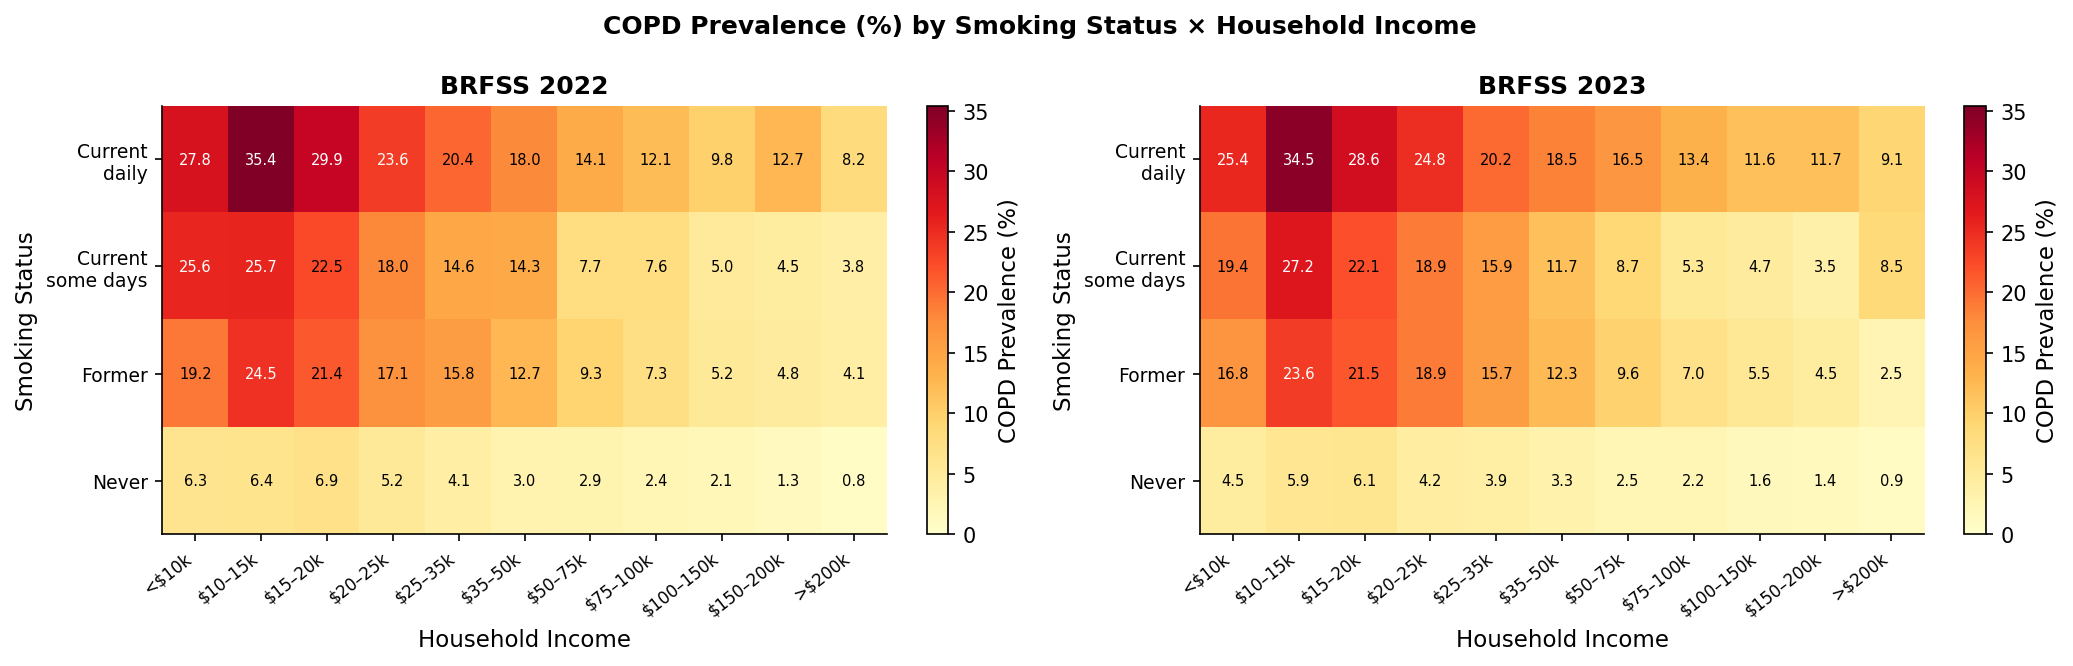

Saved fig04_smoking_income_heatmap.png



In [26]:
# Cell 12: Smoking × Income interaction figure
SMOKER_LABELS = {1: 'Current\ndaily', 2: 'Current\nsome days',
                 3: 'Former', 4: 'Never'}

def smoking_x_income(df):
    rows = []
    for smk in sorted(df['_SMOKER3'].dropna().unique()):
        for inc in sorted(df['INCOME3'].dropna().unique()):
            sub = df[(df['_SMOKER3'] == smk) & (df['INCOME3'] == inc)]
            if len(sub) < 30:
                continue
            w = sub[WEIGHT].fillna(0)
            y = sub[OUTCOME].astype(float)
            rows.append({
                'smoker'    : int(smk),
                'income'    : int(inc),
                'prevalence': np.average(y, weights=w) * 100,
                'n'         : len(sub),
            })
    return pd.DataFrame(rows)

ix22 = smoking_x_income(df22)
ix23 = smoking_x_income(df23)

vmax = max(ix22['prevalence'].max(), ix23['prevalence'].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, (ix, yr) in zip(axes, [(ix22, 2022), (ix23, 2023)]):
    pivot = ix.pivot(index='smoker', columns='income', values='prevalence')
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=vmax)

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(
        [INCOME_LABELS.get(c, str(c)) for c in pivot.columns],
        rotation=38, ha='right', fontsize=8)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(
        [SMOKER_LABELS.get(r, str(r)) for r in pivot.index], fontsize=9)
    ax.set_title(f'BRFSS {yr}')
    ax.set_xlabel('Household Income')
    ax.set_ylabel('Smoking Status')

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                        fontsize=7,
                        color='white' if val > vmax * 0.65 else 'black')
    plt.colorbar(im, ax=ax, label='COPD Prevalence (%)', fraction=0.046)

plt.suptitle('COPD Prevalence (%) by Smoking Status × Household Income',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_smoking_income_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig04_smoking_income_heatmap.png')
print()

In [27]:
#Cell 13: Univariate associations table

def univariate_assoc(df, col):
    sub = df[[col, OUTCOME, WEIGHT]].dropna()
    if sub[col].nunique() < 2:
        return None

    # Chi-squared p-value (unweighted — screening only)
    ct = pd.crosstab(sub[col], sub[OUTCOME])
    try:
        _, pval, _, _ = chi2_contingency(ct)
    except Exception:
        pval = np.nan

    # Weighted prevalence per category
    cat_prev = {}
    for cat in sorted(sub[col].unique()):
        mask = sub[col] == cat
        w    = sub.loc[mask, WEIGHT]
        y    = sub.loc[mask, OUTCOME].astype(float)
        cat_prev[int(cat)] = np.average(y, weights=w) * 100

    return {'pval': pval, 'cat_prev': cat_prev, 'n_cats': sub[col].nunique()}

print(f'{"Variable":<20}  {"n_cats":>6}  {"p-value":>10}  {"COPD % by category (first 4 cats)"}')
print('-' * 90)

results = {}
for col in FEATURE_COLS:
    res = univariate_assoc(df22, col)
    if res is None:
        continue
    results[col] = res
    cats_str = '  '.join([f'cat{k}={v:.1f}%'
                           for k, v in list(res['cat_prev'].items())[:4]])
    pstr = f'{res["pval"]:.2e}' if res['pval'] is not None else 'N/A'
    print(f'{VAR_LABELS.get(col, col):<20}  {res["n_cats"]:>6}  {pstr:>10}  {cats_str}')

Variable              n_cats     p-value  COPD % by category (first 4 cats)
------------------------------------------------------------------------------------------
Household income (1–11)      11    0.00e+00  cat1=14.0%  cat2=17.4%  cat3=14.9%  cat4=11.4%
Education level (1–6)       6    0.00e+00  cat1=5.0%  cat2=9.7%  cat3=12.7%  cat4=8.1%
Sex                        2   8.02e-104  cat1=5.9%  cat2=7.6%
Age group (5-yr bands)      13    0.00e+00  cat1=2.0%  cat2=2.5%  cat3=2.4%  cat4=3.4%
Race/ethnicity             6    0.00e+00  cat1=8.0%  cat2=7.0%  cat3=1.5%  cat4=10.6%
Employment status          8    0.00e+00  cat1=3.2%  cat2=3.8%  cat3=7.9%  cat4=5.0%
Marital status             6    0.00e+00  cat1=5.8%  cat2=12.4%  cat3=15.6%  cat4=10.4%
Urban/Rural                2    3.76e-85  cat1=6.6%  cat2=10.1%
Smoking status             4    0.00e+00  cat1=19.8%  cat2=13.1%  cat3=11.1%  cat4=3.0%
Any exercise (past 30d)       2    0.00e+00  cat0=12.2%  cat1=5.0%
Any alcohol (past 30d)    

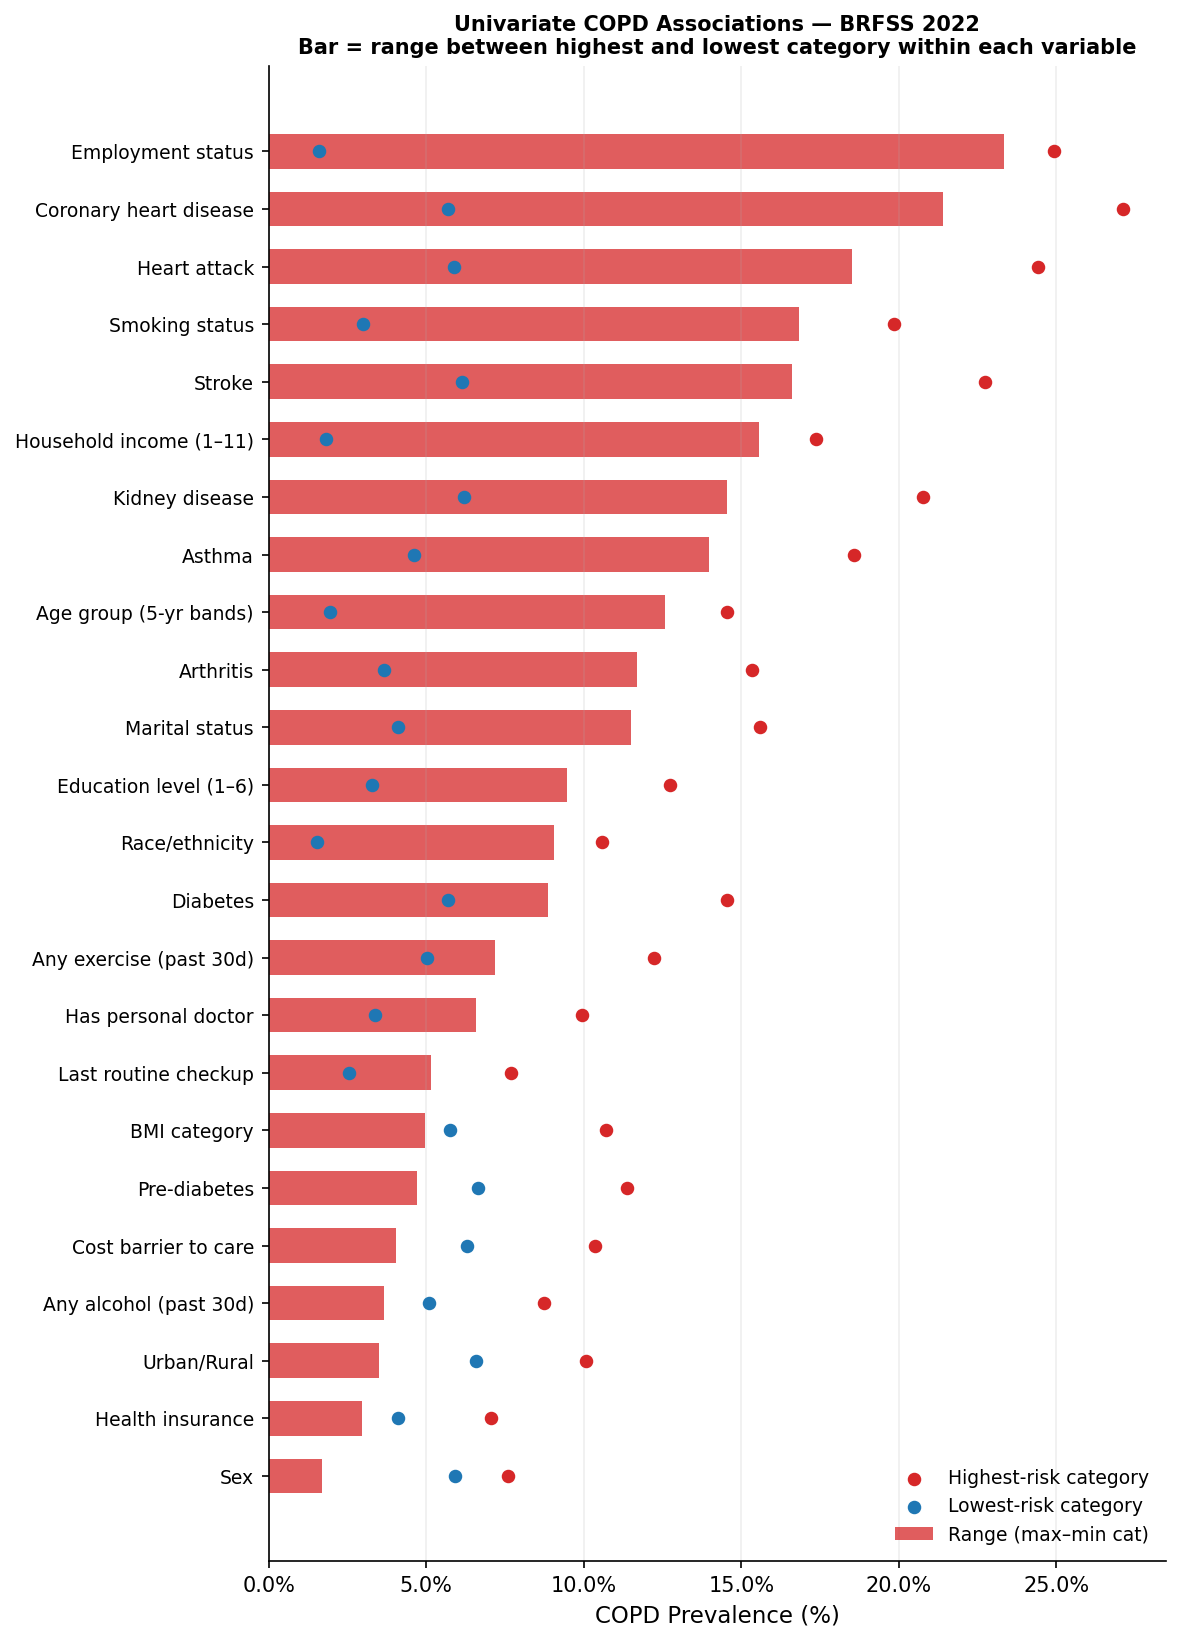

Saved fig05_univariate_associations.png


In [28]:
#Cell 14: univariate forest plot

records = []
for col in FEATURE_COLS:
    if col not in df22.columns:
        continue
    sub = df22[[col, OUTCOME, WEIGHT]].dropna()
    if sub[col].nunique() < 2:
        continue

    # For binary/low-cardinality vars: compare cat with highest COPD prev
    # against lowest. For ordinal vars: compare first vs last category.
    cats = sorted(sub[col].unique())

    def wprev(cat_val):
        mask = sub[col] == cat_val
        w = sub.loc[mask, WEIGHT]
        y = sub.loc[mask, OUTCOME].astype(float)
        if w.sum() == 0:
            return np.nan
        return np.average(y, weights=w) * 100

    prevs = {int(c): wprev(c) for c in cats}
    max_prev = max(prevs.values())
    min_prev = min(prevs.values())
    diff     = max_prev - min_prev

    records.append({
        'col'      : col,
        'label'    : VAR_LABELS.get(col, col),
        'max_prev' : max_prev,
        'min_prev' : min_prev,
        'diff'     : diff,
    })

plot_df = pd.DataFrame(records).sort_values('diff', ascending=True)

fig, ax = plt.subplots(figsize=(8, len(plot_df) * 0.42 + 1))
y = np.arange(len(plot_df))

ax.barh(y, plot_df['diff'], color=COPD_RED, alpha=0.75, height=0.6, label='Range (max–min cat)')
ax.scatter(plot_df['max_prev'], y, color=COPD_RED, zorder=3, s=30, label='Highest-risk category')
ax.scatter(plot_df['min_prev'], y, color=SAFE_BLUE, zorder=3, s=30, label='Lowest-risk category')

ax.set_yticks(y)
ax.set_yticklabels(plot_df['label'], fontsize=9)
ax.set_xlabel('COPD Prevalence (%)')
ax.set_title('Univariate COPD Associations — BRFSS 2022\n'
             'Bar = range between highest and lowest category within each variable',
             fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_univariate_associations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig05_univariate_associations.png')

In [34]:
# Cell 15: weighted summary table with p-values

BINARY_VARS = {
    'SEXVAR'    : {1: 'Male', 2: 'Female'},
    '_URBSTAT'  : {1: 'Urban', 2: 'Rural'},
    'EXERANY2'  : {1: 'Yes', 0: 'No'},
    'DRNKANY6'  : {1: 'Yes', 0: 'No'},
    'ASTHMA3'   : {1: 'Yes', 0: 'No'},
    'CVDINFR4'  : {1: 'Yes', 0: 'No'},
    'CVDCRHD4'  : {1: 'Yes', 0: 'No'},
    'CVDSTRK3'  : {1: 'Yes', 0: 'No'},
    'HAVARTH3'  : {1: 'Yes', 0: 'No'},
    'CHCKDNY2'  : {1: 'Yes', 0: 'No'},
    'HLTHPLN2'  : {1: 'Yes', 0: 'No'},
    'MEDCOST1'  : {1: 'Yes', 0: 'No'},
    'DIABETES'  : {1: 'Yes', 0: 'No'},
    'PREDIABETES': {1: 'Yes', 0: 'No'},
}

ORDINAL_VARS = {
    '_SMOKER3'  : {1: 'Current daily', 2: 'Current some days', 3: 'Former', 4: 'Never'},
    '_BMI5CAT'  : {1: 'Underweight', 2: 'Normal', 3: 'Overweight', 4: 'Obese'},
    'PERSDOC3'  : {1: 'Yes, one', 2: 'Yes, >1', 3: 'No'},
    'CHECKUP1'  : {1: '<1 yr', 2: '1-2 yr', 3: '2-5 yr', 4: '>5 yr', 8: 'Never'},
}

def wtd_col_pct(df, col, cat_val):
    """Weighted % of respondents in this column category."""
    sub = df[[col, WEIGHT]].dropna()
    mask = sub[col] == cat_val
    return sub.loc[mask, WEIGHT].sum() / sub[WEIGHT].sum() * 100

def wtd_mean(df, col):
    sub = df[[col, WEIGHT]].dropna()
    return np.average(sub[col], weights=sub[WEIGHT])

def get_pvalue(df, col):
    """Chi-squared p-value for association with COPD outcome."""
    sub = df[[col, OUTCOME]].dropna()
    if sub[col].nunique() < 2:
        return np.nan
    ct = pd.crosstab(sub[col], sub[OUTCOME])
    try:
        _, pval, _, _ = chi2_contingency(ct)
        return pval
    except Exception:
        return np.nan

rows = []
rows.append({
    'Variable': 'DEMOGRAPHICS & SOCIOECONOMIC STATUS',
    'Category': '',
    'No COPD': '',
    'COPD': '',
    'Overall': '',
    'p_value': '',
})

# Income/education/age means
for col, label in [
    ('INCOME3', 'Household income (1-11)'),
    ('EDUCA', 'Education level (1-6)'),
    ('_AGEG5YR', 'Age group (5-yr bands)'),
]:
    pval = get_pvalue(df22, col)
    row = {'Variable': label, 'Category': 'mean'}
    for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
        sub = df22[df22[OUTCOME] == grp]
        row[name] = f'{wtd_mean(sub, col):.2f}'
    row['Overall'] = f'{wtd_mean(df22, col):.2f}'
    row['p_value'] = f'{pval:.2e}' if not np.isnan(pval) else 'N/A'
    rows.append(row)

# Sex
pval = get_pvalue(df22, 'SEXVAR')
for idx, (cat_val, cat_label) in enumerate({1: 'Male', 2: 'Female'}.items()):
    row = {'Variable': 'Sex', 'Category': cat_label}
    for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
        sub = df22[df22[OUTCOME] == grp]
        row[name] = f"{wtd_col_pct(sub, 'SEXVAR', cat_val):.1f}%"
    row['Overall'] = f"{wtd_col_pct(df22, 'SEXVAR', cat_val):.1f}%"
    row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
    rows.append(row)

# Race/ethnicity
pval = get_pvalue(df22, '_IMPRACE')
for idx, (cat_val, cat_label) in enumerate({
    1: 'White, non-Hispanic',
    2: 'Black, non-Hispanic',
    3: 'Other race, non-Hispanic',
    4: 'Multiracial, non-Hispanic',
    5: 'Hispanic',
    6: 'Other race only, non-Hispanic',
}.items()):
    row = {'Variable': 'Race/ethnicity', 'Category': cat_label}
    for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
        sub = df22[df22[OUTCOME] == grp]
        row[name] = f'{wtd_col_pct(sub, "_IMPRACE", cat_val):.1f}%'
    row['Overall'] = f'{wtd_col_pct(df22, "_IMPRACE", cat_val):.1f}%'
    row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
    rows.append(row)

# Employment status
pval = get_pvalue(df22, 'EMPLOY1')
for idx, (cat_val, cat_label) in enumerate({
    1: 'Employed for wages',
    2: 'Self-employed',
    3: 'Out of work >=1 year',
    4: 'Out of work <1 year',
    5: 'Homemaker',
    6: 'Student',
    7: 'Retired',
    8: 'Unable to work',
}.items()):
    row = {'Variable': 'Employment status', 'Category': cat_label}
    for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
        sub = df22[df22[OUTCOME] == grp]
        row[name] = f'{wtd_col_pct(sub, "EMPLOY1", cat_val):.1f}%'
    row['Overall'] = f'{wtd_col_pct(df22, "EMPLOY1", cat_val):.1f}%'
    row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
    rows.append(row)

# Marital status
pval = get_pvalue(df22, 'MARITAL')
for idx, (cat_val, cat_label) in enumerate({
    1: 'Married',
    2: 'Divorced',
    3: 'Widowed',
    4: 'Separated',
    5: 'Never married',
    6: 'Unmarried couple',
}.items()):
    row = {'Variable': 'Marital status', 'Category': cat_label}
    for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
        sub = df22[df22[OUTCOME] == grp]
        row[name] = f'{wtd_col_pct(sub, "MARITAL", cat_val):.1f}%'
    row['Overall'] = f'{wtd_col_pct(df22, "MARITAL", cat_val):.1f}%'
    row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
    rows.append(row)

# Urban/rural
pval = get_pvalue(df22, '_URBSTAT')
for idx, (cat_val, cat_label) in enumerate({1: 'Urban', 2: 'Rural'}.items()):
    row = {'Variable': 'Urban/Rural', 'Category': cat_label}
    for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
        sub = df22[df22[OUTCOME] == grp]
        row[name] = f"{wtd_col_pct(sub, '_URBSTAT', cat_val):.1f}%"
    row['Overall'] = f"{wtd_col_pct(df22, '_URBSTAT', cat_val):.1f}%"
    row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
    rows.append(row)

rows.append({'Variable': 'BEHAVIORAL', 'Category': '', 'No COPD': '', 'COPD': '', 'Overall': '', 'p_value': ''})
for col, var_label, cat_map in [
    ('EXERANY2', 'Any exercise (past 30 days)', {1: 'Yes', 0: 'No'}),
    ('DRNKANY6', 'Any alcohol (past 30 days)', {1: 'Yes', 0: 'No'}),
    ('_SMOKER3', 'Smoking status', {1: 'Current daily', 2: 'Current some days', 3: 'Former', 4: 'Never'}),
    ('_BMI5CAT', 'BMI category', {1: 'Underweight', 2: 'Normal', 3: 'Overweight', 4: 'Obese'}),
]:
    pval = get_pvalue(df22, col)
    for idx, (cat_val, cat_label) in enumerate(cat_map.items()):
        row = {'Variable': var_label, 'Category': cat_label}
        for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
            sub = df22[df22[OUTCOME] == grp]
            row[name] = f'{wtd_col_pct(sub, col, cat_val):.1f}%'
        row['Overall'] = f'{wtd_col_pct(df22, col, cat_val):.1f}%'
        row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
        rows.append(row)

rows.append({'Variable': 'COMORBIDITIES', 'Category': '', 'No COPD': '', 'COPD': '', 'Overall': '', 'p_value': ''})
for col, var_label, cat_map in [
    ('ASTHMA3', 'Asthma', {1: 'Yes', 0: 'No'}),
    ('CVDINFR4', 'Heart attack', {1: 'Yes', 0: 'No'}),
    ('CVDCRHD4', 'Coronary heart disease', {1: 'Yes', 0: 'No'}),
    ('CVDSTRK3', 'Stroke', {1: 'Yes', 0: 'No'}),
    ('HAVARTH3', 'Arthritis', {1: 'Yes', 0: 'No'}),
    ('CHCKDNY2', 'Kidney disease', {1: 'Yes', 0: 'No'}),
    ('DIABETES', 'Diabetes', {1: 'Yes', 0: 'No'}),
    ('PREDIABETES', 'Pre-diabetes', {1: 'Yes', 0: 'No'}),
]:
    pval = get_pvalue(df22, col)
    for idx, (cat_val, cat_label) in enumerate(cat_map.items()):
        row = {'Variable': var_label, 'Category': cat_label}
        for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
            sub = df22[df22[OUTCOME] == grp]
            row[name] = f'{wtd_col_pct(sub, col, cat_val):.1f}%'
        row['Overall'] = f'{wtd_col_pct(df22, col, cat_val):.1f}%'
        row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
        rows.append(row)

rows.append({'Variable': 'ACCESS TO CARE', 'Category': '', 'No COPD': '', 'COPD': '', 'Overall': '', 'p_value': ''})
for col, var_label, cat_map in [
    ('HLTHPLN2', 'Has health insurance', {1: 'Yes', 0: 'No'}),
    ('MEDCOST1', 'Cost barrier to care', {1: 'Yes', 0: 'No'}),
    ('PERSDOC3', 'Has personal doctor', {1: 'Yes, one', 2: 'Yes, more than one', 3: 'No'}),
    ('CHECKUP1', 'Last routine checkup', {1: 'Less than 1 year', 2: '1-2 years', 3: '2-5 years', 4: 'More than 5 years', 8: 'Never'}),
]:
    pval = get_pvalue(df22, col)
    for idx, (cat_val, cat_label) in enumerate(cat_map.items()):
        row = {'Variable': var_label, 'Category': cat_label}
        for grp, name in [(0, 'No COPD'), (1, 'COPD')]:
            sub = df22[df22[OUTCOME] == grp]
            row[name] = f'{wtd_col_pct(sub, col, cat_val):.1f}%'
        row['Overall'] = f'{wtd_col_pct(df22, col, cat_val):.1f}%'
        row['p_value'] = f'{pval:.2e}' if (idx == 0 and not np.isnan(pval)) else ('N/A' if idx == 0 else '')
        rows.append(row)

n_copd = int(df22[OUTCOME].sum())
n_no_copd = int((df22[OUTCOME] == 0).sum())

table1 = pd.DataFrame(rows)
table1.columns = [
    'Variable',
    'Category',
    f'No COPD (n={n_no_copd:,})',
    f'COPD (n={n_copd:,})',
    'Overall',
    'p-value',
]

print(f'BRFSS 2022 | No COPD: n={n_no_copd:,} | COPD: n={n_copd:,} | Total: n={len(df22):,}')
print(table1.to_string(index=False))

with open(TABLE_DIR / 'table1_descriptive_stats.csv', 'w') as f:
    f.write('Values are survey-weighted percentages unless otherwise noted. Means reported for ordinal scale variables. All p-values from chi-squared test.\n\n')
    table1.to_csv(f, index=False)
    f.write('\n\nCOPD = chronic obstructive pulmonary disease; BRFSS = Behavioral Risk Factor Surveillance System. All percentages are survey-weighted. COPD defined by affirmative response to CHCCOPD3.')

print('\nSaved table1_descriptive_stats.csv with section headers and notes')

BRFSS 2022 | No COPD: n=407,257 | COPD: n=35,656 | Total: n=442,913
                           Variable                      Category No COPD (n=407,257) COPD (n=35,656) Overall   p-value
DEMOGRAPHICS & SOCIOECONOMIC STATUS                                                                                    
            Household income (1-11)                          mean                6.93            5.38    6.82  0.00e+00
              Education level (1-6)                          mean                4.78            4.36    4.75  0.00e+00
             Age group (5-yr bands)                          mean                6.10            8.60    6.27  0.00e+00
                                Sex                          Male               49.1%           42.4%   48.7% 8.02e-104
                                Sex                        Female               50.9%           57.6%   51.3%          
                     Race/ethnicity           White, non-Hispanic               58.4%       

In [ ]:
# Cell 16: Final EDA summary and export tables

grad22.to_csv(TABLE_DIR / 'eda_income_gradient_2022.csv', index=False)
grad23.to_csv(TABLE_DIR / 'eda_income_gradient_2023.csv', index=False)
ix22.to_csv(TABLE_DIR  / 'eda_smoking_income_2022.csv',   index=False)
ix23.to_csv(TABLE_DIR  / 'eda_smoking_income_2023.csv',   index=False)

rho22, _ = spearmanr(grad22['income_val'], grad22['prevalence'])
rho23, _ = spearmanr(grad23['income_val'], grad23['prevalence'])

print('=== EDA SUMMARY ===\n')
print(f'  2022 weighted COPD prevalence : {p22:.2f}%')
print(f'  2023 weighted COPD prevalence : {p23:.2f}%')
print(f'  Class ratio 2022              : 1 : {(df22[OUTCOME]==0).sum()/df22[OUTCOME].sum():.1f}')
print(f'  Class ratio 2023              : 1 : {(df23[OUTCOME]==0).sum()/df23[OUTCOME].sum():.1f}')
print()
print(f'  Income gradient Spearman ρ — 2022 : {rho22:.3f}')
print(f'  Income gradient Spearman ρ — 2023 : {rho23:.3f}')
hi22_g = grad22.loc[grad22['income_val'].idxmin(), 'prevalence']
lo22_g = grad22.loc[grad22['income_val'].idxmax(), 'prevalence']
print(f'  Fold-gradient 2022            : {hi22_g/lo22_g:.1f}× ({hi22_g:.1f}% vs {lo22_g:.1f}%)')
print()
print('  Figures saved:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'    {f.name}')
print()
print('  Tables saved:')
for f in sorted(TABLE_DIR.glob('*.csv')):
    print(f'    {f.name}')
print()
print('Next: notebooks/03_baseline_models.ipynb')

=== EDA SUMMARY ===

  2022 weighted COPD prevalence : 6.76%
  2023 weighted COPD prevalence : 6.19%
  Class ratio 2022              : 1 : 11.4
  Class ratio 2023              : 1 : 12.0

  Income gradient Spearman ρ — 2022 : -0.973
  Income gradient Spearman ρ — 2023 : -0.945
  Fold-gradient 2022            : 7.7× (14.0% vs 1.8%)

  Figures saved:
    fig01_missingness.png
    fig02_class_balance.png
    fig03_income_gradient.png
    fig04_smoking_income_heatmap.png
    fig05_univariate_associations.png

  Tables saved:
    eda_income_gradient_2022.csv
    eda_income_gradient_2023.csv
    eda_smoking_income_2022.csv
    eda_smoking_income_2023.csv
    table1_descriptive_stats.csv

Next: notebooks/03_baseline_models.ipynb
